In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT=Path.cwd().parent
df=pd.read_csv(ROOT/'data'/'raw'/'Churn_Modelling.csv')

df=df.drop(columns=['RowNumber','CustomerId','Surname'])

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True)*100)

(10000, 11)
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


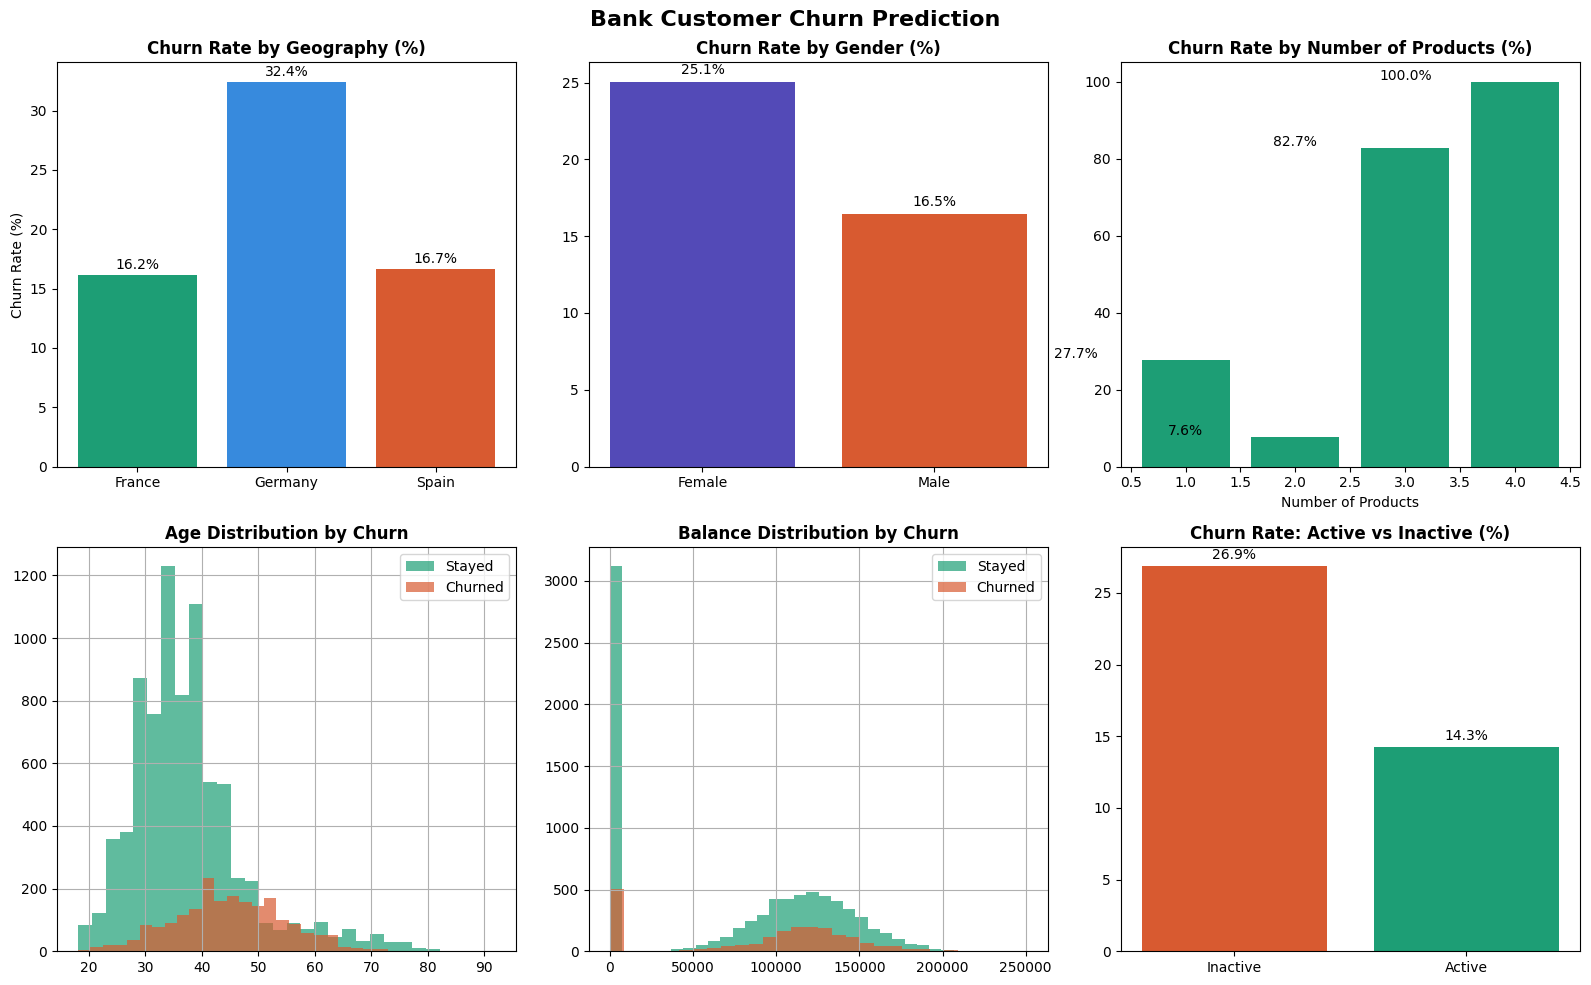

In [3]:
fig,axes=plt.subplots(2,3,figsize=(16,10))

#Churn by Geography
churn_geo=df.groupby('Geography')['Exited'].mean()*100
axes[0,0].bar(churn_geo.index,churn_geo.values,color=['#1D9E75','#378ADD','#D85A30'])
axes[0,0].set_title('Churn Rate by Geography (%)',fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(churn_geo.values):
    axes[0,0].text(i,v+0.5,f'{v:.1f}%',ha='center',fontsize=10)

#Churn by Gender
churn_gender=df.groupby('Gender')['Exited'].mean()*100
axes[0,1].bar(churn_gender.index,churn_gender.values,color=['#534AB7','#D85A30'])
axes[0,1].set_title('Churn Rate by Gender (%)',fontweight='bold')
for i, v in enumerate(churn_gender.values):
    axes[0,1].text(i,v+0.5,f'{v:.1f}%',ha='center',fontsize=10)

#Churn by Number of Products
churn_pod=df.groupby('NumOfProducts')['Exited'].mean()*100
axes[0,2].bar(churn_pod.index,churn_pod.values,color='#1D9E75')
axes[0,2].set_title('Churn Rate by Number of Products (%)',fontweight='bold')
axes[0,2].set_xlabel('Number of Products')
for i, v in enumerate(churn_pod.values):
    axes[0,2].text(i,v+0.5,f'{v:.1f}%',ha='center',fontsize=10)


#Age distribution by churn
df[df['Exited']==0]['Age'].hist(ax=axes[1,0],bins=30,alpha=0.7,color='#1D9E75',label='Stayed')
df[df['Exited']==1]['Age'].hist(ax=axes[1,0],bins=30,alpha=0.7,color='#D85A30',label='Churned')
axes[1,0].set_title('Age Distribution by Churn',fontweight='bold')
axes[1,0].legend()


#Balance Distribution by Churn
df[df['Exited']==0]['Balance'].hist(ax=axes[1,1],bins=30,alpha=0.7,color='#1D9E75',label='Stayed')
df[df['Exited']==1]['Balance'].hist(ax=axes[1,1],bins=30,alpha=0.7,color='#D85A30',label='Churned')
axes[1,1].set_title('Balance Distribution by Churn',fontweight='bold')
axes[1,1].legend()


#Active member churn rate
churn_active=df.groupby('IsActiveMember')['Exited'].mean()*100
axes[1,2].bar(['Inactive','Active'],churn_active.values,color=['#D85A30','#1D9E75'])
axes[1,2].set_title('Churn Rate: Active vs Inactive (%)',fontweight='bold')
for i,v in enumerate(churn_active.values):
    axes[1,2].text(i,v+0.5,f'{v:.1f}%',ha='center',fontsize=10)

plt.suptitle('Bank Customer Churn Prediction',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda_overview.png',dpi=150,bbox_inches='tight')
plt.show()

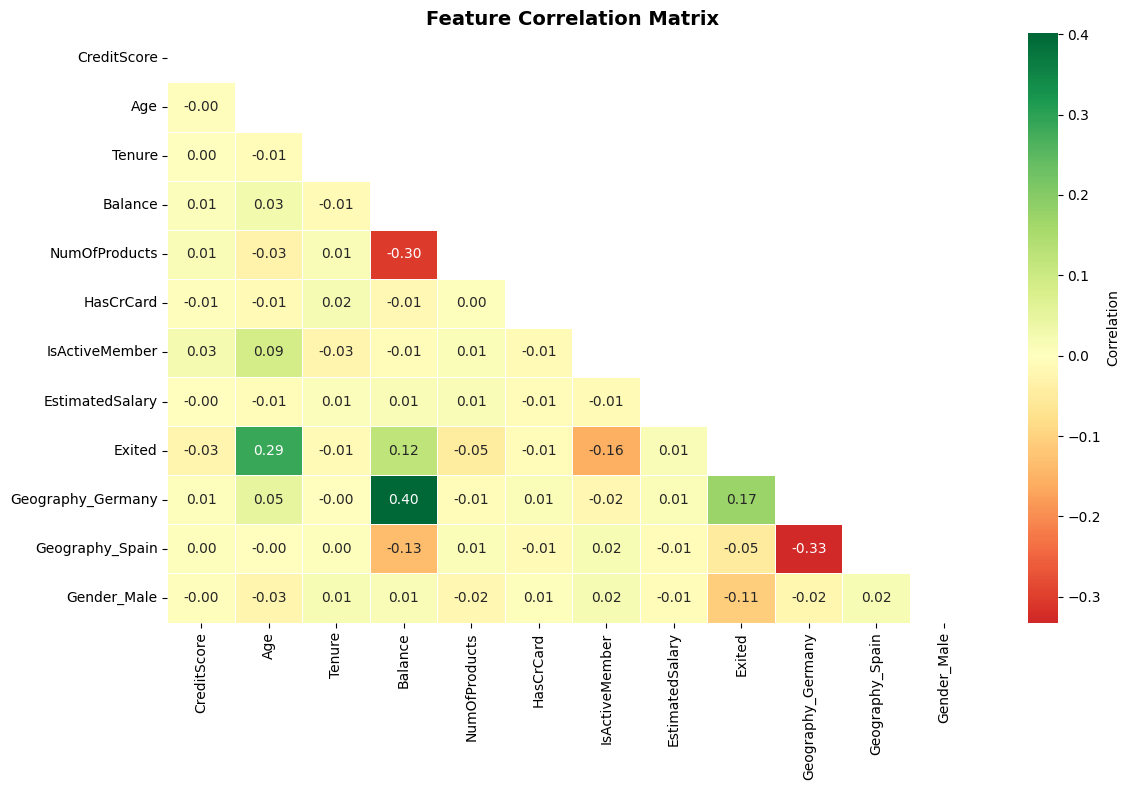

Correlation with Exited (churn):
Exited               1.000000
Age                  0.285323
Geography_Germany    0.173488
Balance              0.118533
EstimatedSalary      0.012097
HasCrCard           -0.007138
Tenure              -0.014001
CreditScore         -0.027094
NumOfProducts       -0.047820
Geography_Spain     -0.052667
Gender_Male         -0.106512
IsActiveMember      -0.156128


In [4]:
df_encoded=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

plt.figure(figsize=(12,8))
corr=df_encoded.corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='RdYlGn',center=0,linewidths=0.5,cbar_kws={'label':'Correlation'})
plt.title('Feature Correlation Matrix',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()

print('Correlation with Exited (churn):')
print(corr['Exited'].sort_values(ascending=False).to_string())

In [5]:
# Save cleaned data
df.to_csv('../data/processed/bank_clean.csv', index=False)
print(f'Saved bank_clean.csv — {df.shape[0]:,} rows x {df.shape[1]} cols')

Saved bank_clean.csv — 10,000 rows x 11 cols
